# Prompting language models through APIs

## Learning goals

By the end of this notebook, you will be able to:

- Send a chat prompt through Hugging Face using two different Python clients.
- Select the model and the company that runs it.
- Adjust decoding settings, including temperature and nucleus sampling.
- Disable optional thinking on a model and provider that support it.
- Request a JSON response matching a Pydantic schema and validate the result.

We use a fictional politician's social media post throughout, so that changes in the API call are easy to compare.
All model inference happens on a remote service.
You do _not_ need a GPU, PyTorch, or downloaded model weights.

<!-- Note: We use the same fictional politician's social media post as in the [`transformer` `pipeline`-based notebook](llm_inference_basics_transformers_pipeline.qmd). -->

::: {.callout-note title="Inference"}

In the context of working with LLMs, _inference_ means generating predictions or responses from a trained language model based on the input you provide.

:::

## Setup

### The route taken by a request

Our requests follow this route:

**Python client → Hugging Face router → selected inference provider → model**

The **client** is a Python package that sends HTTP requests.
We use the Hugging Face Inference Client or the OpenAI Python client as our two different clients.

The **provider** operates the servers.
The **model** is the trained language model those servers run.
Changing the client does not necessarily change the provider or model.

This notebook uses Hugging Face **Inference Providers**, accessed through API endpoints.
<!-- The separately named product **Inference Endpoints** deploys dedicated infrastructure and is not needed here. -->
We authenticate with a Hugging Face token.
See the [HF inference overview](https://huggingface.co/docs/huggingface_hub/package_reference/inference_client).

### Authentication and access

::: {.callout-warning title="Access/API token"}

You need a Hugging Face access token to authenticate with the Inference Providers.

Create a [Hugging Face access token](https://huggingface.co/settings/tokens) with permission to make Inference Providers calls.

How to do this is described in [this guide](https://github.com/haukelicht/advanced_text_analysis/blob/main/setup/setup_hugging_face_pro.md#3-create-an-access-token).

:::

::: {.callout-warning title="API credit"}

Your account also needs sufficient credit.

Follow [this guide](https://github.com/haukelicht/advanced_text_analysis/blob/main/setup/setup_hugging_face_pro.md#2-upgrade-to-a-pro-subscription) to link a credit card to your Hugging Face _Pro_ account.

:::

The setup cell reads `HF_TOKEN` if it is already defined. Otherwise, an interactive notebook asks for it without displaying the characters. Do not paste a real token into a saved code cell.

In [1]:
import os

# Reuse an environment variable, or ask without echoing the secret.
hf_token = os.environ.get("HF_TOKEN", None)
if hf_token is None:
    raise ValueError("A Hugging Face token is required. set as `HF_TOKEN` in .env file")

### Choose an explicit provider and model

We start with `Qwen/Qwen2.5-72B-Instruct` and provider _DeepInfra_ (`deepinfra`).
<!-- Later we use an original Qwen3 model to demonstrate its thinking switch. -->
<!-- For structured outputs, we use the Qwen3-32B/Cerebras combination illustrated in the [HF structured-output guide](https://huggingface.co/docs/inference-providers/guides/structured-output). This avoids assuming that support for one feature implies support for another. -->

::: {.callout-tip title="Provider catalog notice"}

Provider catalogs change.
I laste checked that the model is supported by the selected provider on 16 September 2026.

Check <https://huggingface.co/inference/models> for an up-to-date list of available models and the providers that serve them.

:::

In [2]:
# Keep model and provider choices in one place.
MODEL_ID = "Qwen/Qwen2.5-72B-Instruct"
PROVIDER = "deepinfra"
HF_BASE_URL = "https://router.huggingface.co/v1"

The [Qwen2.5-72B-Instruct model page](https://huggingface.co/Qwen/Qwen2.5-72B-Instruct) lists provider availability.
Selecting `provider="auto"` is convenient, but explicit selection makes your choice clearer.

## First request: Hugging Face's client

### Define the conversation

A chat request contains a list of messages.
Each message has a `role` and `content`. 

There are three roles:

- A `system` message gives general task instructions.
- A `user` message supplies the question or material to analyse.
- An `assistant` message represents a previous model response.


We use the example of classifying the sentiment expressed in a post written by a fictious politican.

> Great news for our town! Today the council approved funding for a new public library.
> I am delighted that we can give everyone more places to learn, meet, and connect.
> Proud of what we have achieved together!"

In [3]:
post_text = (
    "Great news for our town! Today the council approved funding for a new "
    "public library. I am delighted that we can give everyone more places "
    "to learn, meet, and connect. Proud of what we have achieved together!"
)
print(post_text)

Great news for our town! Today the council approved funding for a new public library. I am delighted that we can give everyone more places to learn, meet, and connect. Proud of what we have achieved together!


::: {.callout-tip title="Fictitious post"}

The post below is invented for teaching and is not attributed to a real politician. 

:::

Let's define a somple task instruction that asks for a sentiment: classification.

In [4]:
task_instruction = """\
You classify the sentiment expressed in politicians' social media posts.

Identify the sentiment as positive, negative, or neutral.

Only return the classification result without any explanation.\
"""

Now we can bring these intputs together in a `messages` list that serves as LLM prompt.

In [5]:
messages = [
    {"role": "system", "content": task_instruction},
    {"role": "user", "content": post_text},
]

::: {.callout-tip title="Using system and user messages"}

We pass the task instruction as a `system` message and the to-be-classified post as a `user` message.
Alternatively, we could include the task instruction directly in the `user` message, but using a `system` message helps separate the general instructions from the specific content to analyze.

:::

### Create a client and send the request

The client stores connection settings.
When instantiating the client, no network request is made.
The request only occurs when calling `chat_completion()` further down.

In [6]:
from huggingface_hub import InferenceClient

hf_client = InferenceClient(
    provider=PROVIDER,   # Select the company running the model.
    api_key=hf_token,     # Authenticate through Hugging Face.
    timeout=60,           # Stop waiting after 60 seconds.
)

Having instantiated the client, we are ready to send a request to the model.
<!-- Note that Wwe cap the response at 120 tokens. A token is a unit of text used by the model, often a word fragment rather than a whole word. -->

In [7]:
response = hf_client.chat.completions.create(
    model=MODEL_ID,
    messages=messages,
)

Let's inspect the `response` object.

In [8]:
type(response)

huggingface_hub.inference._generated.types.chat_completion.ChatCompletionOutput

It's a `ChatCompletionOutput` instance.
This class is dedicated to representing the output of a chat completion request, including the generated messages and associated metadata.

`ChatCompletionOutput` have the following attributes:

In [9]:
print(*list(response.__dict__.keys()), sep="\n")

choices
created
id
model
system_fingerprint
usage
service_tier
object


- `choices`: A list of completion choices returned by the model.
- `created`: The timestamp when the completion was created.
- `id`: The unique identifier for the completion request.
- `model`: The model used to generate the completion.
- `system_fingerprint`: A fingerprint representing the system state.
- `usage`: Token usage information for the request.
- `service_tier`: The service tier used for the request.
- `object`: The type of the object returned (usually "chat.completion").

We are most interested of the `choices` attribute, which contains the generated messages from the model.
It's a list of completion choices, where each choice contains a generated message and associated metadata.
Since we have only generated one completion, we can safely access the first element of the list.

In [10]:
print(response.choices[0])

ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content='positive', reasoning=None, tool_call_id=None, tool_calls=None, reasoning_content=None, name=None), logprobs=None)


The element is a `ChatCompletionOutputComplete` instance.
This class represents a single completion choice returned by the model, including the generated message and associated metadata.

Most relevant is its `message` attribute, which contains the generated message from the model (the "assistant"):

In [11]:
print(response.choices[0].message)

ChatCompletionOutputMessage(role='assistant', content='positive', reasoning=None, tool_call_id=None, tool_calls=None, reasoning_content=None, name=None)


The message is a `ChatCompletionOutputMessage` instance with a few attributes, most imporantly:

- `role`: The role of the message sender (e.g., "assistant"). This shows that this message is one that the model (the assistant) has generated
- `content`: The content of the message.

Finally, the message content can be accessed directly through the `content` attribute:

In [12]:
print(response.choices[0].message.content)

positive


This response message the assistant has generated is the **classification choice** we tasked it to produce.

::: {.callout-tip title="Congratulations"}

You have successfully used an LLM to complete a text annotation task!

:::

#### Other response details

In [13]:
print("Finish reason:", response.choices[0].finish_reason)
print("Token usage:", response.usage)

Finish reason: stop
Token usage: ChatCompletionOutputUsage(completion_tokens=1, prompt_tokens=89, total_tokens=90, estimated_cost=3.244e-05, prompt_tokens_details=None)


- the **finish reason** indicates why the model stopped generating a response. You want it to be `"stop"` because this means the model completed its output as expected. When you see `"length"`, it means the model stopped because it reached the maximum token limit. In this case, you should increase this limit (how to is shown further below).
- the **token usage** provides information about how many tokens were consumed by the request (see `prompt_tokens`) and how many were generated (see `completion_tokens`),which can help you manage costs and understand model behavior.

All response fields are documented in the [InferenceClient reference](https://huggingface.co/docs/huggingface_hub/package_reference/inference_client#huggingface_hub.InferenceClient.chat_completion).

## The same request with the OpenAI Python package

Most LLM inference APIs are designed to be compatible with the OpenAI API, allowing you to use the same request structure and client libraries.

“OpenAI-compatible” describes an API standard that defines which parameters you can use and how requests should be structured.
This includes the conventions of using the parameter `model` for specifying which model to use and `messages` for passing the conversation history to the model.

We can use the `openai` package to send requests to Hugging Face by setting `base_url`. We still use the same Hugging Face token and model.

The HF router accepts a provider suffix in the model string.
Thus `Qwen/Qwen2.5-1.5B-Instruct:featherless-ai` plays the same routing role as the separate model and provider settings above. 
See [HF chat-completion examples](https://huggingface.co/docs/inference-providers/tasks/chat-completion).

In [14]:
from openai import OpenAI

openai_client = OpenAI(
    base_url=HF_BASE_URL,  # Send requests to HF, not OpenAI's service.
    api_key=hf_token,
    timeout=60,
    max_retries=0,        # Make failures visible during the lesson.
)

model_id = f"{MODEL_ID}:{PROVIDER}" # use f-string inserts both variables.
# NOTE: this is specific to using hugging face inference providers API


In [15]:
response = openai_client.chat.completions.create(
    model=model_id,
    messages=messages,
    max_tokens=120,
)

print(response.choices[0].message.content)

positive


::: {.callout-note title="Getting inconstient responses?"}

Sometimes, the model may produce slightly different responses even for the same input. This is expected behavior due to the probabilistic nature of the decoding process.

We'll discuss strategies for making independent responses to the prompt (more) consistent later in the course.

:::

### Connection settings and required inputs

| Setting | Where it belongs | Requirement and purpose |
|---|---|---|
| `api_key` | Client constructor | Authentication for these examples; contains the HF token. It is sent in an authorization header, not a chat message. |
| `base_url` | OpenAI client constructor | Required here to target HF's router. The HF client handles routing itself. |
| `provider` | HF client constructor | _Optional_ in the Hugging Face SDK; set explicitly here. In the OpenAI examples, use the `:provider` model suffix. |
| `model` | Completion call | Explicitly supplied throughout; selects the model. Some HF methods can choose a default, but we avoid that. |
| `messages` | Completion call | Required conversation input: a list of role/content dictionaries. A system message is optional. |
| `timeout` | Client constructor | _Optional_ upper bound on waiting; unrelated to the output token limit. |

## Controlling text generation

LLMs like Qwen **generate text** by predicting one token at a time based on the preceding context.
Choosing which token to return at each step of the generation process is referred to as **decoding**.

To understand _decoding_ strategies, it's important to understand that at each generation step, a model computes scores called **logits** for possible next tokens.
These correspond to the probabilities of each token in the model's vocabulary of being returned at the given generation step.

::: {.callout-note title="Next token probability example"}

Say the model has so far generated the sequence of tokens:

`["The", "cat", "sat", "on", "the"]`

The model then computes what's the probability of its token to be next in this sequence.

This will likely give a token like "table" or "mat" a higher probability than less contextually appropriate tokens, like "banana" or "car".

:::

### "Greedy decoding"

In greedy decoding, the model always selects the token with the highest probability at each generation step.

For scientific use, the advantage of this strategy is that it is deterministic (holding constant the model and compute environment).

We enable greedy decoding by passing the extra API parameter `do_sample=False`.

The following experiment shows this.
We define a random number generation prompt.

In [16]:
random_number_choice_prompt = """\
Choose an integer between 1 and 100.\
Pick one you like best.\
Only return the number and nothing else.\
"""

Running the model without switching off sampling, you likely get different responses across the five repeated requests:

In [17]:
for _ in range(5):
    response = hf_client.chat.completions.create(
        model=MODEL_ID,
        messages=[{"role": "user", "content": random_number_choice_prompt}],
    )
    print(response.choices[0].message.content)

7
73
42
27
42


But if you enable greedy decoding by setting `do_sample=False` and `temperature=0` (see further below), the model will consistently return the same response across repeated requests:

In [18]:
for _ in range(5):
    response = hf_client.chat.completions.create(
        model=MODEL_ID,
        messages=[{"role": "user", "content": random_number_choice_prompt}],
        extra_body={"do_sample": False}, # enable greedy decoding
        temperature=0,
    )
    print(response.choices[0].message.content)

42
42
42
42
42


In [19]:
for _ in range(5):
    response = hf_client.chat.completions.create(
        model=MODEL_ID,
        messages=[{"role": "user", "content": random_number_choice_prompt}],
        extra_body={"do_sample": False}, # enable greedy decoding
        temperature=2,
        max_tokens=12,
    )
    print(response.choices[0].message.content)

73
42
7
27
42


::: {.callout-note title="extra_body parameters are provider dependent"}

The `extra_body` parameters, such as `do_sample`, may vary depending on the provider and the specific model implementation.
For providers serving models available on Hugging Face Hub, the `extra_body` parameters should align with the options supported by the specific model implementation on the Hub.

But when in doubt, try a short API request and see if it succeeds or, better, consult the provider's documentation for the exact parameters supported.

:::


::: {.callout-note title="Getting inconsistent responses even with greedy decoding?"}

There is a non-zero chance that you might still get different responses due to factors like server-side randomness, hardware differences, or software updates.

Remember that you send requests to a provider who has a server running many different models and also different instances of the same model.
Your separate requests might get routed to different instances of the model that run on different hardware.
Then there is no guarantee that you will get identical responses every time, even with greedy decoding.

:::


But "greedy decoding" also has an important limitation: it can lead to repetitive or less diverse outputs.

So this is why computer scientists have invented many different sampling strategies to introduce controlled randomness into the generation process.

### Sampling

Sampling settings affect which token is selected from those possibilities.

Details are described [here](https://huggingface.co/docs/transformers/en/generation_strategies) and we'll discuss only some important ones.


#### Temperature: how concentrated is the probability distribution on the most-likely token?

Remember that the model generates a probability distribution over all tokens in its vocabulary to determine the next tokens at each step.

The **temperature** setting modulates how peak or flat this probability distribution is:

- at a value of 1, the probability distribution is used as-is.
- values below 1 make the probability distribution sharper, favoring higher-probability tokens more strongly.
- values above 1 make the probability distribution flatter, increasing the likelihood of sampling lower-probability tokens.

Typical values are between 0.7 and 1.2 for most natural language generation tasks.
For scientific use such as text classification, researchers often use lower values, including 0.0.

Specifically, for a non-zero temperature $T$, the usual temperature transformation is:

$$
p_i = \frac{\exp(z_i/T)}{\sum_j \exp(z_j/T)},
$$

where $z_i$ is the logit for token $i$ and $p_i$ is the resulting probability for token $i$.

The following graphic simulates how different temperature settings affect the probability distribution over six tokens, "1" through "6".

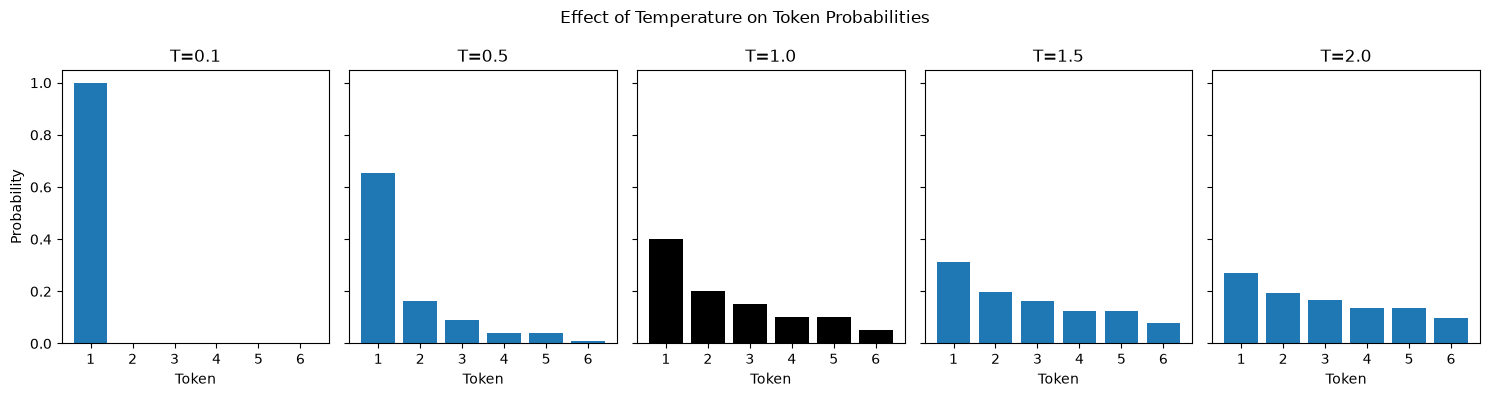

In [20]:
import numpy as np

# sample default probability distribution for six tokens
probs = np.array([0.4, 0.2, 0.15, 0.1, 0.1, 0.05])

import matplotlib.pyplot as plt

def plot_temperature_effect(probs, temperatures):
    tokens = np.arange(1, len(probs) + 1)
    fig, axes = plt.subplots(
        1, len(temperatures), figsize=(3 * len(temperatures), 4), sharey=True
    )
    axes = np.atleast_1d(axes)
    for ax, T in zip(axes, temperatures):
        adjusted_probs = np.exp(np.log(probs) / T)
        adjusted_probs /= adjusted_probs.sum()
        color = 'black' if T == 1.0 else 'tab:blue'
        ax.bar(tokens, adjusted_probs, color=color)
        ax.set_title(f'T={T}')
        ax.set_xlabel('Token')
        ax.set_xticks(tokens)
    axes[0].set_ylabel('Probability')
    fig.suptitle('Effect of Temperature on Token Probabilities')
    fig.tight_layout()
    plt.show()

plot_temperature_effect(probs, [0.1, 0.5, 1.0, 1.5, 2.0])

::: {.callout-warning title="temperature=0.0!?"}

Many researchers write in their reports and recommend to set the temperature to 0.0 to effectively make the model deterministic, always choosing the highest-probability token at each step.

Given the formula above, setting T to 0.0 is not possible though.

What happens instead is that if the user specified `temperature=0` in their API request, sampling is _disabled_ (i.e., greedy decoding _enabled_).

This achieves the same as setting `do_sample=False` or `top_k=1` (see below).

:::

#### Top-k: how many top candidates are considered?

Again, remember that the model generates a probability distribution over all tokens in its vocabulary to determine the next tokens at each step.

But when setting `top_k=k`, only the top `k` tokens are considered for sampling, and all others are ignored.

Typicall values are 5, 10, 20, 50, or 100.

Setting `top_k` helps to limit the model's choices to a manageable set of plausible options while still allowing some randomness.

### Top-p: how many alternatives remain eligible?

Nucleus sampling (`top_p`) retains the smallest set of highest-probability tokens whose cumulative probability reaches the threshold. 
If probabilities are 0.60, 0.25, 0.10, and 0.05, a threshold of 0.80 retains the first two candidates, whose combined probability is 0.85. Sampling then operates on the retained set.

### (Other) (optional) request parameters

The names below are common in OpenAI-compatible chat APIs.
Actual acceptance, ranges, and defaults depend on the provider and model.

| Parameter | Example | Effect |
|---|---|---|
| `max_tokens` | `150` | Caps generated length; may include reasoning tokens depending on the backend. A small budget can truncate an answer. |
| `temperature` | `0.2` | Makes sampling more concentrated at low positive values and more varied at higher values. |
| `top_p` | `0.9` | Restricts candidates by cumulative probability. `1.0` applies no nucleus cutoff. |
| `frequency_penalty` | `0.2` | Positive values penalize tokens according to how often they have appeared. |
| `presence_penalty` | `0.2` | Positive values penalize tokens that have appeared, without scaling by their count. |
| `stop` | `["END"]` | Stops at a supplied string. This can cut off JSON prematurely. |
| `seed` | `42` | Requests reproducibility where supported; not a guarantee across server configurations. |
| `stream` | `True` | Delivers incremental chunks instead of waiting for the full response; changes consumption of the response. |
| `response_format` | JSON Schema dictionary | Requests a specified output format; requires backend support. |
| `logprobs` | `True` | Requests log probabilities for generated tokens where supported; does not itself control decoding. |
| `top_logprobs` | `5` | Requests alternative tokens' log probabilities alongside selected tokens; needs `logprobs=True`. |

::: {.callout-warning title="omitted ≠ disabled"}

A parameter you omit in your request is not necessarily disabled!

Instead it falls back to a default value.

Check the default values whenever you are unsure.

:::

::: {.callout-warning title="max_tokens ≠ max_completion_tokens"}

Do not assume `max_completion_tokens` is interchangeable with `max_tokens` on all HF providers.

This notebook uses the latter, as documented for HF Chat Completions.

For definitions and accepted values, consult the [HF API reference](https://huggingface.co/docs/inference-providers/tasks/chat-completion#api-specification).

:::

### An optional experiment

This cell makes **three additional requests**. It asks for a short campaign slogan so that wording variation is easier to observe than with a single classification label.
One output per setting illustrates the API, but is not enough to estimate variability statistically.

In [21]:
creative_messages = [
    {
        "role": "user", 
        "content": "Write one short, cheerful social media announcement about a new public library that fits into a tweet/X post."
    }
]

for temperature in (0.2, 0.7, 1.0):
    response = hf_client.chat_completion(
        model=MODEL_ID,
        messages=creative_messages,
        max_tokens=260,
        temperature=temperature,  # Change only this control across requests.
        top_p=1.0, # sample from all tokens 
    )
    print(temperature, response.choices[0].message.content)

0.2 📚✨ Exciting news! Our new public library is now open! Dive into a world of endless stories and knowledge. Everyone's invited to explore, learn, and connect. Welcome to your new community hub! 🎉 #LibraryLove #CommunityGrowsHere
0.7 📚 Exciting news! Our brand-new public library is now open! Dive into a world of books, resources, and community. Welcome to your new favorite spot! 🎉 #LibraryLove #NewLibrary #ReadAndRelate
1.0 📚 Exciting news! Our brand-new public library is now open! Dive into a world of endless stories and knowledge. Everyone's welcome! 🎉 #NewLibrary #ReadAndRoam


**Discuss:** 
To study variability properly, how many repeated requests would you want at each temperature? 
Which other settings would you record?